In [25]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [26]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)

In [27]:
log_normalization_constants_ar = np.array([PKLs[i]['res'][7] for i in list_idx_ar])
log_normalization_constants_rwmh = np.array([PKLs[i]['res'][7] for i in list_idx_rwmh])

In [28]:
log_normalization_constants_ar.shape

(1, 10, 36)

<Axes: >

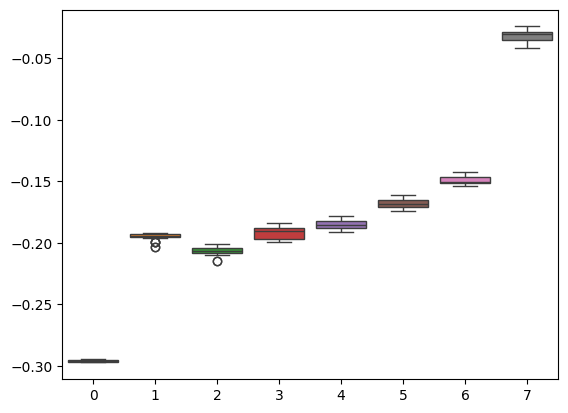

In [64]:
import seaborn as sns
import pandas as pd
df = pd.concat([pd.DataFrame(log_normalization_constants_rwmh.reshape((10, 36))[...,:8]).assign(type="RW"), pd.DataFrame(log_normalization_constants_ar.reshape((10, 36))[...,:8]).assign(type="AR")], axis=1)
sns.boxplot(data=df)

In [68]:
df[0]

,0,0
0,-0.297216,-0.297216
1,-0.296096,-0.296096
2,-0.297196,-0.297196
3,-0.297119,-0.297119
4,-0.294664,-0.294664
5,-0.295321,-0.295321
6,-0.295696,-0.295696
7,-0.297254,-0.297254
8,-0.295610,-0.295610
9,-0.295392,-0.295392


In [102]:
df1 = pd.DataFrame(log_normalization_constants_rwmh.reshape((10, 36))[...,:8], columns=list(range(1,9))).assign(Type='RW')
df2 = pd.DataFrame(log_normalization_constants_ar.reshape((10, 36))[...,:8], columns=list(range(1,9))).assign(Type='AR')


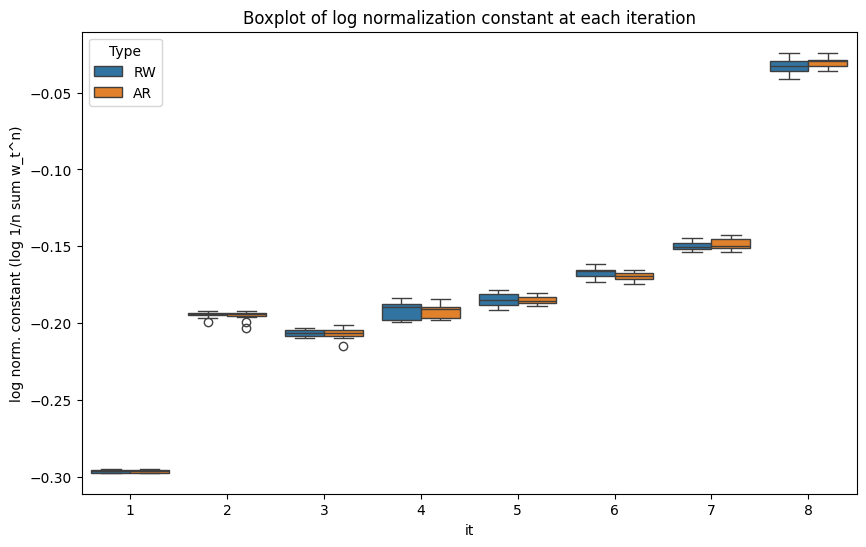

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrames
df1 = df1

df2 = df2

# Combine the DataFrames
combined_df = pd.concat([df1, df2])

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', hue='Type', data=melted_df)

# Add titles and labels
plt.title('Boxplot of log normalization constant at each iteration')
plt.xlabel('it')
plt.ylabel('log norm. constant (log 1/n sum w_t^n)')

# Show the plot
plt.show()